In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ricardofernandes99/fgreerftfer/Dataset-iGov (2).csv


## 1. Import The Necessary Libraries 

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

## 2. Load the data from the uploaded CSV file

In [7]:
data = pd.read_csv('/kaggle/input/datasets/ricardofernandes99/fgreerftfer/Dataset-iGov (2).csv')

## 3. Display the first few rows of the dataset and information about the dataset

In [8]:
print(data.head())
print(data.info())

   id_registo data_registo                    unidade_organizacional  \
0           1   2024-04-12          Direcção De Serviços Financeiros   
1           2   2024-12-14  Departamento De Inovação E Digitalização   
2           3   2024-09-27              Direcção De Recursos Humanos   
3           4   2024-04-16   Departamento De Planeamento Estratégico   
4           5   2024-03-12              Direcção De Recursos Humanos   

             tipo_servico  indicador_si  taxa_resolucao  tempo_resposta  \
0                Telefone         83.02           87.37              36   
1            Balcão Único         75.53           89.71              29   
2                 Chatbot         85.73           75.96              38   
3                   Email         78.33           73.82              57   
4  Atendimento Presencial         81.82           70.41              97   

   satisfacao_cidadao  volume_interacoes  canal_utilizado  taxa_abandono  \
0                 3.8                368

## 5. Train the model with RandomForestRegressor

In [35]:
X = data.drop(columns=['indicador_kpi','data_registo'])
y = data['indicador_kpi']

In [36]:
data.head()

,id_registo,data_registo,unidade_organizacional,tipo_servico,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,canal_utilizado,taxa_abandono,erros_tecnicos,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica,indicador_kpi
0,1,2024-04-12,Direcção De Serviços Financeiros,Telefone,83.02,87.37,36,3.8,368,Presencial,22.41,7,Sim,Processo Complicado,Empresa,Cultura,63.13
1,2,2024-12-14,Departamento De Inovação E Digitalização,Balcão Único,75.53,89.71,29,4.1,349,Email,14.87,1,Sim,Bom Serviço,Funcionário Público,Saúde,63.58
2,3,2024-09-27,Direcção De Recursos Humanos,Chatbot,85.73,75.96,38,3.3,398,Telefone,15.42,5,Não,Processo Complicado,Estudante,Inovação,73.64
3,4,2024-04-16,Departamento De Planeamento Estratégico,Email,78.33,73.82,57,3.4,74,Aplicacao_Movel,15.32,11,Sim,Processo Complicado,Funcionário Público,Digitalização,99.19
4,5,2024-03-12,Direcção De Recursos Humanos,Atendimento Presencial,81.82,70.41,97,4.7,487,Portal,7.47,4,Sim,Serviço Eficiente,Cidadão,Saúde,63.45


In [37]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# Preprocess categorical features
categorical_features = ['unidade_organizacional', 'tipo_servico', 'canal_utilizado','transparencia','feedback_cidadao','segmentacao_utilizador','area_tematica']
preprocessor = ColumnTransformer(
    transformers=[
        ('encode_categories', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [40]:
# Create a pipeline with a RandomForestRegressor 
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


In [41]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encode_categories',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['unidade_organizacional',
                                                   'tipo_servico',
                                                   'canal_utilizado',
                                                   'transparencia',
                                                   'feedback_cidadao',
                                                   'segmentacao_utilizador',
                                                   'area_tematica'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

## 6. Make predictions and predictions score

In [42]:
y_pred = model.predict(X_test)

In [43]:
model.score(X_test,y_test)

-0.0542033302586451

The Root Mean Squared Error (RMSE) is a commonly used metric to evaluate the accuracy of a regression model

In [44]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print(f'Root Mean Squared Error (RMSE): {rmse}')

Root Mean Squared Error (RMSE): 12.873761510248285


## 7. Plot actual vs predicted values

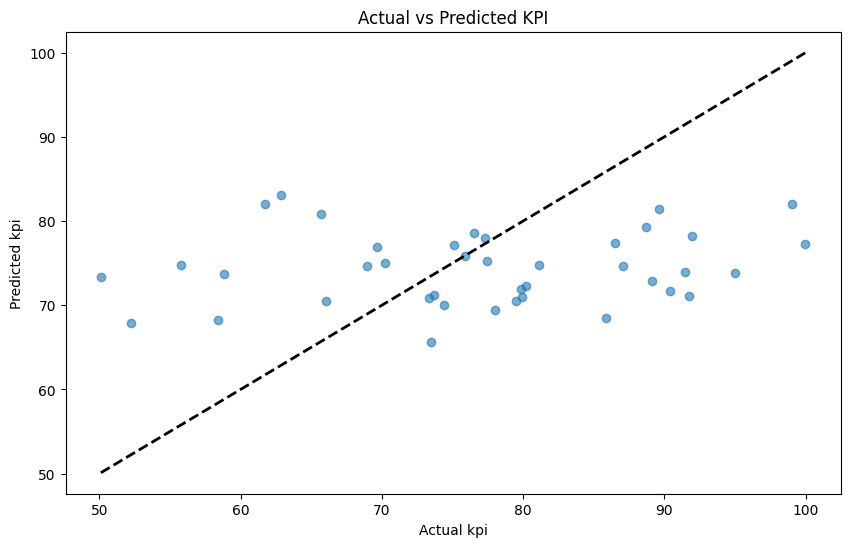

In [46]:

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual kpi')
plt.ylabel('Predicted kpi')
plt.title('Actual vs Predicted KPI')
plt.show()